In [6]:
%run "/home/nichettg/Codici/Laboratorio/moduli.py"

In [ ]:
def nome (stringa):
    """
    Estrae il nome, cioè la frequenza, dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace('./Data/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [8]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [9]:
gf.display_dizionario(dati)

# 2. Analisi

## 2.1 Confronto Frequenze Forzanti

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


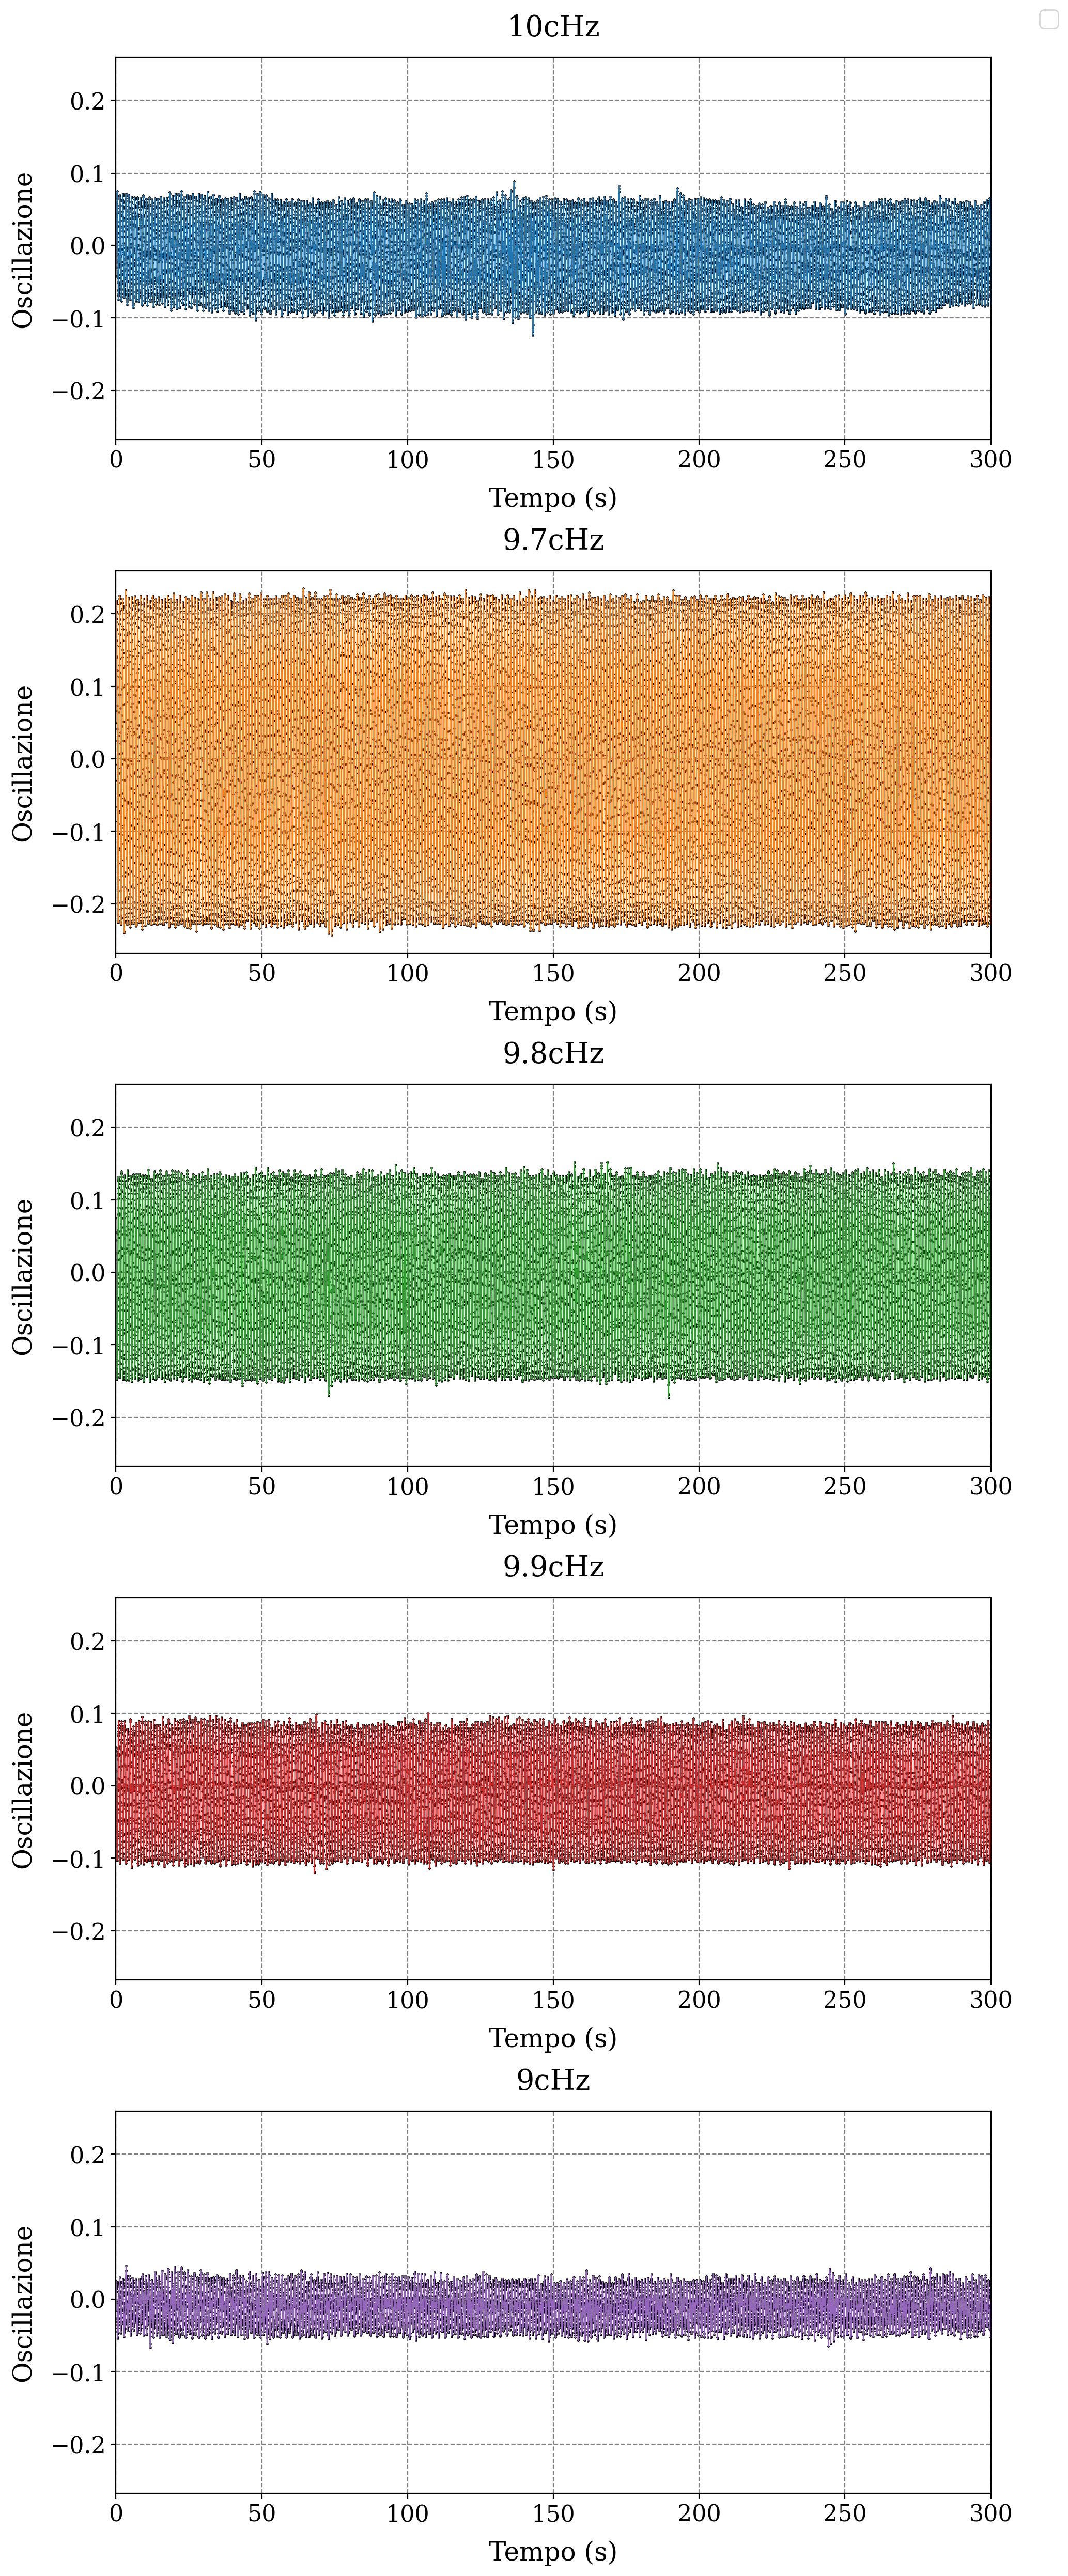

In [49]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"]

    """
    y1 = dati[titolo]["ampiezza"] / (2*np.pi) # ampiezza (soluzione) in rad
    y2 = dati[titolo]["forzante"] / (2*np.pi) / 1000 # ampiezza forzante in rad

    ax.plot(x, y1, color=colore, linewidth=0.7)
    ax.scatter(x, y1, color="black", s=0.7)

    ax.plot(x, y2, color=gf.darken(colore), linewidth=0.7)
    ax.scatter(x, y2, color="black", s=0.7)
    """

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/ConfrontoForzanti.pdf")

## 2.2 Calcolo Ampiezze Medie

Raggio dell'intorno rispetto al quale i valori salvati sono i massimi. Di tali valori verrà poi calcolata la media, considerata come ampiezza media.

In [52]:
raggio = 40
grafico_controllo = False

In [53]:
ampiezze = {}

if grafico_controllo: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati):
    valori = dati[serie]["pendolo"]
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []

    for j, val in enumerate(valori):
        if tempi[j] > 300:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])

    ampiezze[serie] = np.mean(massimi)

    print(f"Serie {serie}: {len(massimi)} massimi \n Media: {np.mean(massimi):.3f} \n Deviazione standard: {np.std(massimi):.3f} \n")
    
    if grafico_controllo:
        ax = axes[i]
        colore = next(color_cycle_fisso)
        ax.scatter(massimi_t, massimi, color=colore)
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Ampiezza")
if grafico_controllo: gf.salva_grafico(fig, f"./Images/ConfrontoMassimi.pdf")

Serie 10cHz: 249 massimi 
 Media: 0.063 
 Deviazione standard: 0.005 

Serie 9.7cHz: 256 massimi 
 Media: 0.223 
 Deviazione standard: 0.003 

Serie 9.8cHz: 242 massimi 
 Media: 0.137 
 Deviazione standard: 0.004 

Serie 9.9cHz: 240 massimi 
 Media: 0.087 
 Deviazione standard: 0.004 

Serie 9cHz: 208 massimi 
 Media: 0.031 
 Deviazione standard: 0.005 



In [ ]:
gf.display_dizionario(ampiezze)

10cHz,0.06327309236947791
9.7cHz,0.22326562500000002
9.8cHz,0.13725619834710748
9.9cHz,0.08747499999999998
9cHz,0.03053846153846155


## 2.3 Fit Lorentziano

---

$$
L(x) = \frac{A}{(x - x_0)^2 + \gamma^2}
$$

dove:

- \( $A$ ) è un parametro legato all'altezza del picco  
- \( $x_0$ ) è la frequenza di risonanza (posizione del picco)  
- \( $\gamma$ ) è la larghezza a metà altezza (HWHM)

---

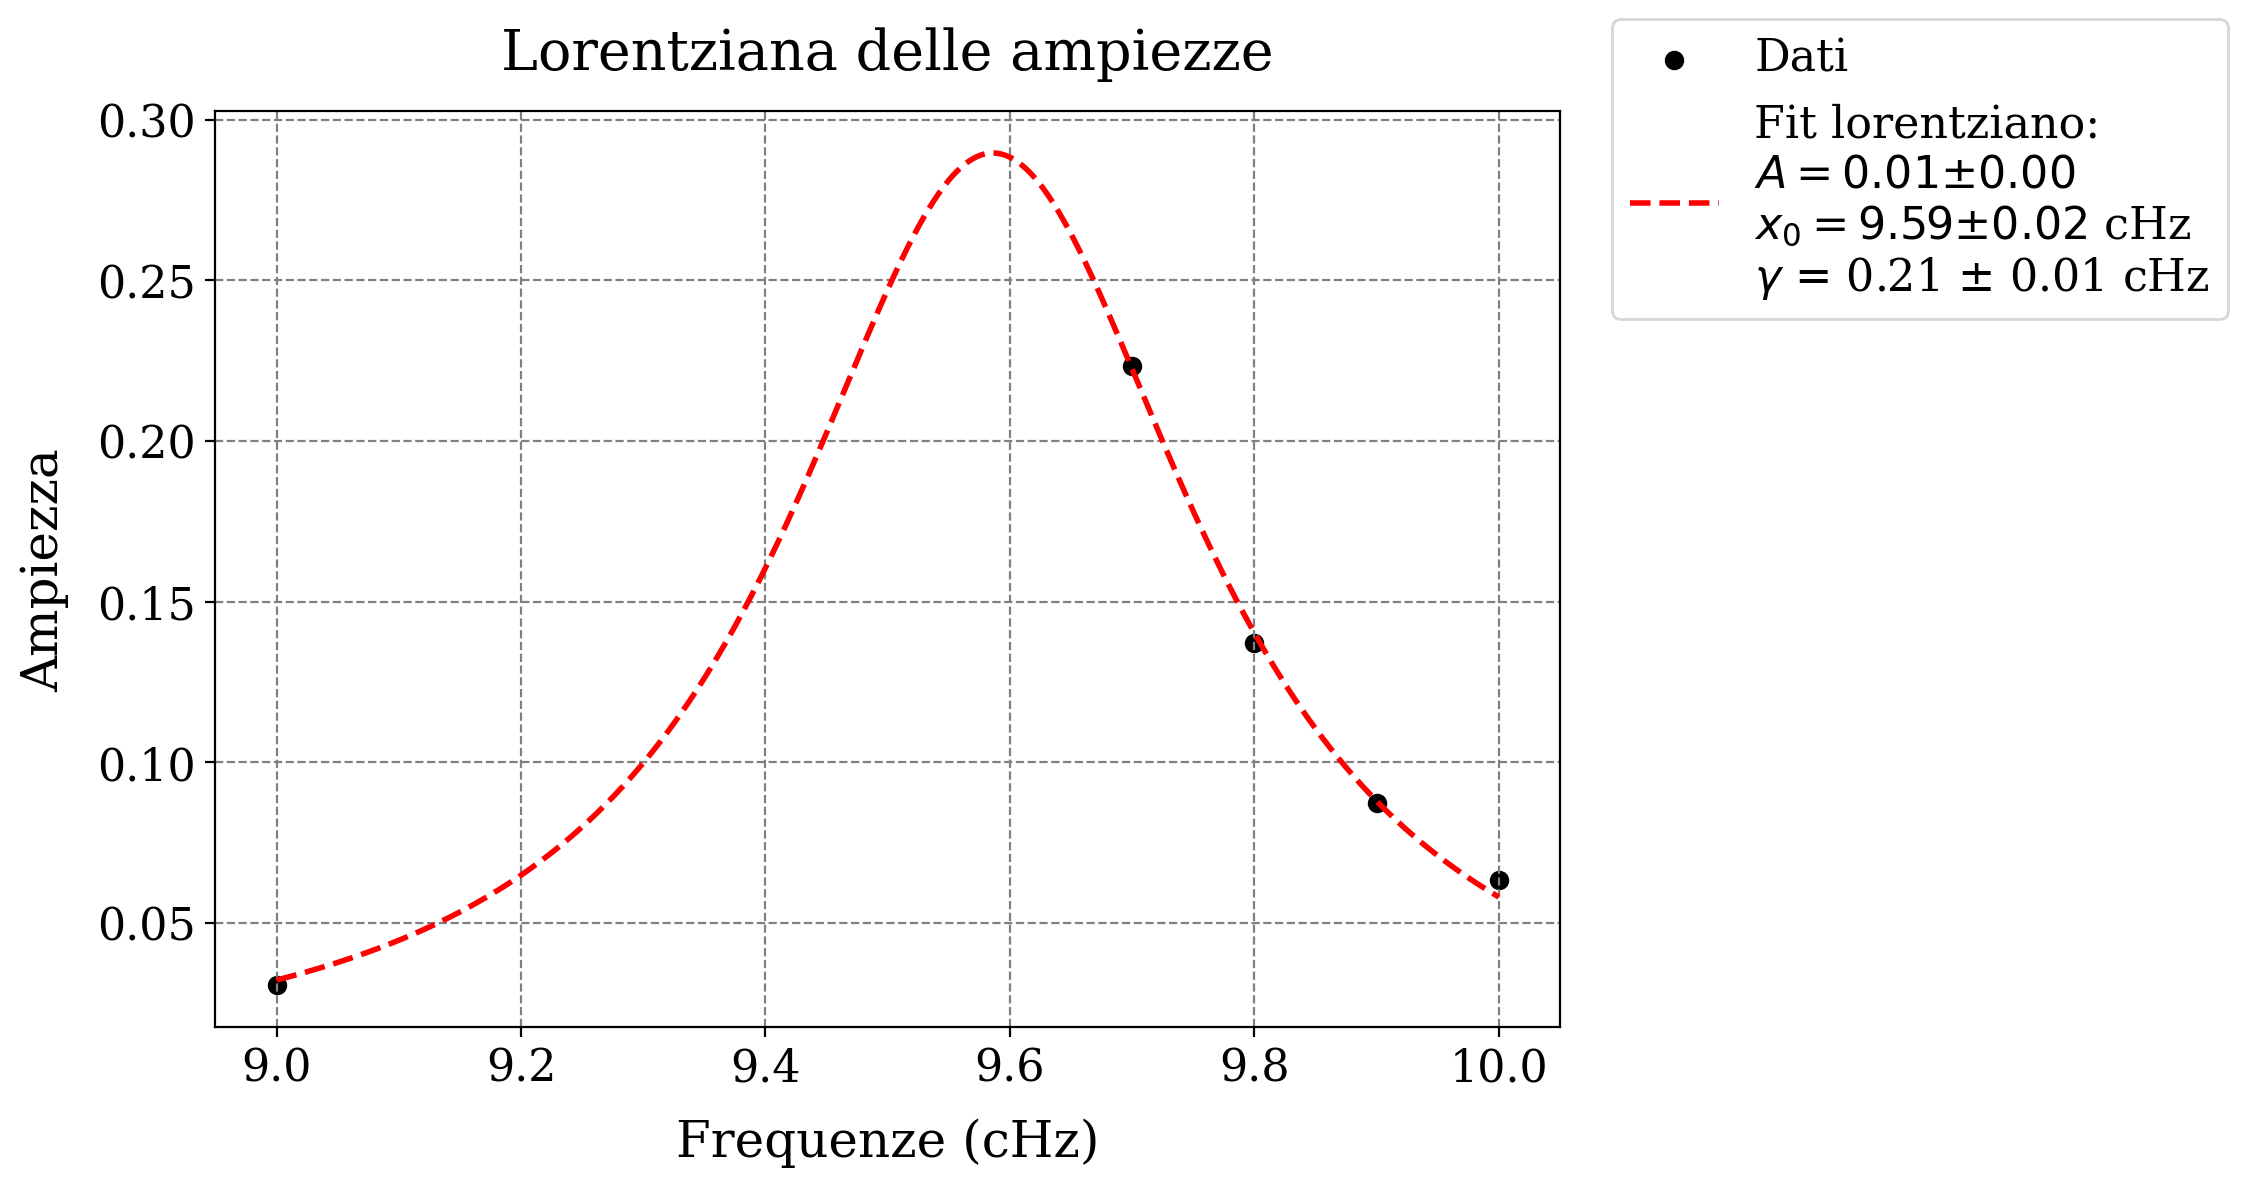

A = 0.012 ± 0.001
x0 = 9.586 ± 0.018
gamma = 0.207 ± 0.008


In [45]:
from scipy.optimize import curve_fit

def lorentziana(x, A, x0, gamma):
    return A / ((x - x0)**2 + gamma**2)

frequenze = [float(key.replace('cHz','')) for key in dati.keys()]
popt, pcov = curve_fit(lorentziana, frequenze, list(ampiezze.values()), p0=[1, np.mean(frequenze), 10])

fig, ax = plt.subplots()
ax.scatter(frequenze, ampiezze_valori, color='black', label='Dati')

perr = np.sqrt(np.diag(pcov))
label_fit = ("\n".join([
    f"Fit lorentziano:",
    f"$A = {popt[0]:.2f} ± {perr[0]:.2f}$",
    f"$x_0 = {popt[1]:.2f} ± {perr[1]:.2f}$ cHz",
    r"$\gamma$"+f" = {popt[2]:.2f} ± {perr[2]:.2f} cHz"])
)

x_fit = np.linspace(min(frequenze), max(frequenze), 1000)
y_fit = lorentziana(x_fit, *popt)
ax.plot(x_fit, y_fit, color='red', label=label_fit, ls='--')

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (cHz)", "Ampiezza")
gf.salva_grafico(fig, "./Images/Lorentziana.pdf")

print(f"A = {popt[0]:.3f} ± {perr[0]:.3f}")
print(f"x0 = {popt[1]:.3f} ± {perr[1]:.3f}")
print(f"gamma = {popt[2]:.3f} ± {perr[2]:.3f}")

## 2.4 Confronto Frequenze Smorzate

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


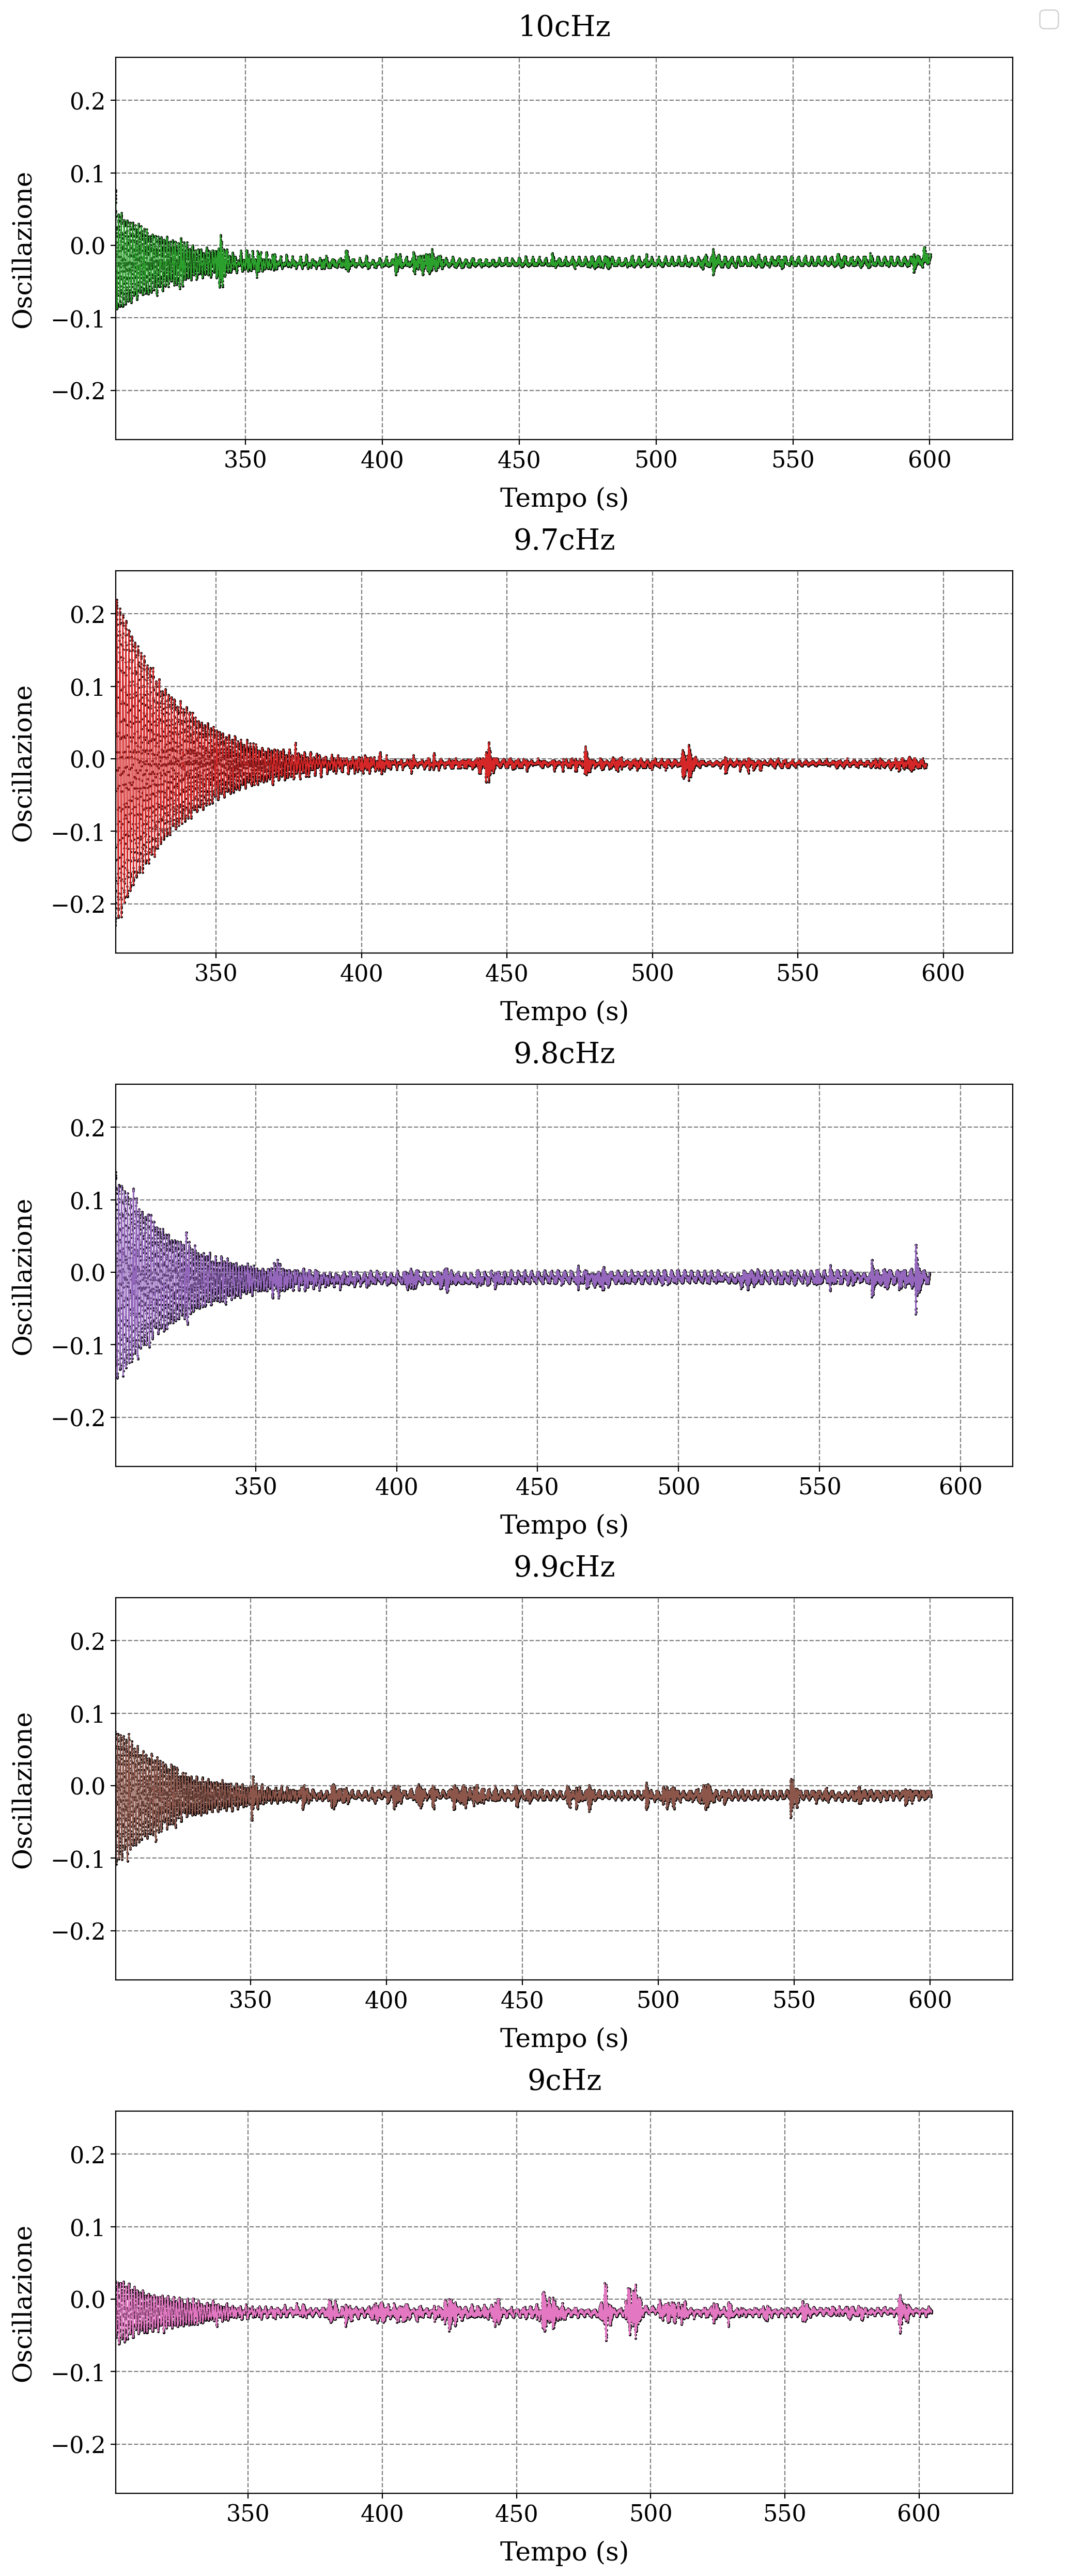

In [59]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"]

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione")

    # Calcolo indice di fine oscillazione forzante (inizio smorzamento)
    fine = np.argmin(abs(dati[titolo]["forzante"]))
    ax.set_xlim(x[fine],None)
gf.salva_grafico(fig, "./Images/ConfrontoSmorzati.pdf")

# Test

In [14]:
for i, serie in enumerate(dati):
    serie = dati[serie]

    tempi = serie['tempo']
    target = 300
    n = np.abs(np.array(tempi) - target).argmin()

    print(f"--- Serie {i+1} ---")
    print(f"Forzante: media = {np.mean(serie['forzante'][:n]):.3f}, deviazione = {np.std(serie['forzante'][:n], ddof=1):.3f}")
    print(f"Pendolo:  media = {np.mean(serie['pendolo'][:n]):.3f},  deviazione = {np.std(serie['pendolo'][:n], ddof=1):.3f}")
    print(f"Ampiezza: media = {np.mean(serie['ampiezza'][:n]):.3f}, deviazione = {np.std(serie['ampiezza'][:n], ddof=1):.3f}")
    print(f"Fase:     media = {np.mean(serie['fase'][:n]):.3f},     deviazione = {np.std(serie['fase'][:n], ddof=1):.3f}\n")

--- Serie 1 ---
Forzante: media = 0.158, deviazione = 23.771
Pendolo:  media = -0.013,  deviazione = 0.052
Ampiezza: media = 0.162, deviazione = 0.009
Fase:     media = 15.009,     deviazione = 1.253

--- Serie 2 ---
Forzante: media = 0.162, deviazione = 23.775
Pendolo:  media = -0.004,  deviazione = 0.159
Ampiezza: media = 0.460, deviazione = 0.004
Fase:     media = 44.750,     deviazione = 0.640

--- Serie 3 ---
Forzante: media = 0.133, deviazione = 23.776
Pendolo:  media = -0.006,  deviazione = 0.099
Ampiezza: media = 0.293, deviazione = 0.006
Fase:     media = 27.823,     deviazione = 0.483

--- Serie 4 ---
Forzante: media = 0.123, deviazione = 23.769
Pendolo:  media = -0.009,  deviazione = 0.067
Ampiezza: media = 0.201, deviazione = 0.004
Fase:     media = 19.695,     deviazione = 0.491

--- Serie 5 ---
Forzante: media = 0.149, deviazione = 23.809
Pendolo:  media = -0.009,  deviazione = 0.024
Ampiezza: media = 0.089, deviazione = 0.006
Fase:     media = 40.059,     deviazione = 17